# Notebook 1 — M5 vs M15 Relative Feature Dataset and Timeframe Feasibility EDA

**Patched version:** this version handles right-labelled final bars so the single `2026-04-01 00:00 UTC` bar is assigned to March 2026 for monthly bar-count plots. It also avoids using partial final-year drift as a scoring driver.


## 1. Colab and project configuration

Upload or sync the generated `data/capstone_methodology` folder into Google Drive. The default expected structure is:

```text
/content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/
  processed/
  reports/data_quality/
  docs/
```

If your folder name is different, edit `PROJECT_ROOT` below.

In [1]:
# Optional: mount Google Drive when running in Colab.
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    print('Not running in Colab, or Google Drive mount is unavailable.')

Mounted at /content/drive


In [2]:
from pathlib import Path
import json
import warnings
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)

# EDIT THIS if your project folder is elsewhere in Google Drive.
if IN_COLAB:
    PROJECT_ROOT = Path('/content/drive/MyDrive/fyp_master_starter')
else:
    PROJECT_ROOT = Path.cwd()

CAPSTONE_DIR = PROJECT_ROOT / 'data' / 'capstone_methodology'
PROCESSED_DIR = CAPSTONE_DIR / 'processed'
REPORT_DIR = CAPSTONE_DIR / 'reports' / 'data_quality'
DOCS_DIR = CAPSTONE_DIR / 'docs'
OUTPUT_DIR = CAPSTONE_DIR / 'notebook_outputs' / '01_m5_m15_timeframe_feasibility_eda'
FIG_DIR = OUTPUT_DIR / 'figures'
TABLE_DIR = OUTPUT_DIR / 'tables'

# Keep notebook outputs reproducible. This clears only this notebook's output folder,
# not the source datasets under data/capstone_methodology/processed.
RESET_OUTPUTS = True
if RESET_OUTPUTS and OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

for d in [OUTPUT_DIR, FIG_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('CAPSTONE_DIR:', CAPSTONE_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)

PROJECT_ROOT: /content/drive/MyDrive/fyp_master_starter
CAPSTONE_DIR: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology
OUTPUT_DIR: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/01_m5_m15_timeframe_feasibility_eda


## 2. Required input files

This notebook expects the outputs generated by the M5/M15 relative dataset preparation and verification scripts. It intentionally reads the regenerated clean capstone methodology folder, not older processed files.

In [3]:
REQUIRED_FILES = {
    'integrity_summary': REPORT_DIR / 'dukascopy_xauusd_m5_m15_relative_pipeline_integrity_summary.json',
    'checklist': REPORT_DIR / 'dukascopy_xauusd_m5_m15_relative_pipeline_checklist.csv',
    'dataset_summary': REPORT_DIR / 'dukascopy_xauusd_m5_m15_dataset_summary.csv',
    'resample_summary': REPORT_DIR / 'dukascopy_xauusd_m5_m15_resample_summary.csv',
    'm5_bars': PROCESSED_DIR / 'dukascopy_xauusd_m5_bars_with_volume.parquet',
    'm15_bars': PROCESSED_DIR / 'dukascopy_xauusd_m15_bars_with_volume.parquet',
    'm5_price': PROCESSED_DIR / 'dukascopy_xauusd_m5_price_only_relative_dataset.parquet',
    'm5_volume': PROCESSED_DIR / 'dukascopy_xauusd_m5_volume_assisted_relative_dataset.parquet',
    'm15_price': PROCESSED_DIR / 'dukascopy_xauusd_m15_price_only_relative_dataset.parquet',
    'm15_volume': PROCESSED_DIR / 'dukascopy_xauusd_m15_volume_assisted_relative_dataset.parquet',
}

missing = [name for name, path in REQUIRED_FILES.items() if not path.exists()]
if missing:
    print('Missing required files:')
    for name in missing:
        print(f' - {name}: {REQUIRED_FILES[name]}')
    raise FileNotFoundError('Upload/sync the missing files before continuing.')

print('All required files found.')

All required files found.


## 3. Integrity gate

Before any EDA, the notebook checks the integrity summary from the verification script. If the pipeline did not pass, the EDA should stop because downstream conclusions would not be reliable.

In [4]:
with open(REQUIRED_FILES['integrity_summary'], 'r', encoding='utf-8') as f:
    integrity = json.load(f)

checklist = pd.read_csv(REQUIRED_FILES['checklist'])
dataset_summary = pd.read_csv(REQUIRED_FILES['dataset_summary'])
resample_summary = pd.read_csv(REQUIRED_FILES['resample_summary'])

print(json.dumps(integrity, indent=2))

if integrity.get('final_status') != 'PASS':
    display(checklist[checklist['status'] != 'PASS'])
    raise ValueError('Integrity gate failed. Fix data pipeline checks before EDA.')

print(f"Integrity gate passed: {integrity['checks_passed']}/{integrity['checks_run']} checks passed.")

{
  "final_status": "PASS",
  "checks_run": 27,
  "checks_passed": 27,
  "checks_failed": 0,
  "failed_checks": [],
  "scope": "This verification checks internal consistency from M1 master to M5/M15 complete bars, relative model datasets, target alignment and feature policy. It does not compare prices against a second market-data provider."
}
Integrity gate passed: 27/27 checks passed.


In [5]:
display(resample_summary)
display(dataset_summary)

resample_summary.to_csv(TABLE_DIR / 'eda_input_resample_summary.csv', index=False)
dataset_summary.to_csv(TABLE_DIR / 'eda_input_dataset_summary.csv', index=False)

,timeframe,bar_minutes,candidate_bars,bars_with_ohlc,complete_bars,incomplete_bars_removed,first_timestamp_utc,last_timestamp_utc,non_contiguous_bar_gaps,maximum_bar_gap_minutes
0,M5,5,1077132,726229,724552,1677,2016-01-03 23:05:00+00:00,2026-04-01 00:00:00+00:00,3750,4585.0
1,M15,15,359044,242126,240636,1490,2016-01-03 23:15:00+00:00,2026-04-01 00:00:00+00:00,3433,4605.0


,timeframe,variant,rows_pre_dropna,rows_final,columns_final,feature_count,target_0_rows,target_1_rows,target_1_rate,mean_target_return_bps,mean_abs_target_return_bps,std_target_return_bps,saved_to
0,M5,price_only,724552,720539,53,50,361326,359213,0.498534,0.009117,3.624223,5.905337,data\capstone_methodology\processed\dukascopy_...
1,M5,volume_assisted,724552,720539,54,51,361326,359213,0.498534,0.009117,3.624223,5.905337,data\capstone_methodology\processed\dukascopy_...
2,M15,price_only,240636,237001,53,50,118189,118812,0.501314,0.021989,6.248668,10.199067,data\capstone_methodology\processed\dukascopy_...
3,M15,volume_assisted,240636,237001,54,51,118189,118812,0.501314,0.021989,6.248668,10.199067,data\capstone_methodology\processed\dukascopy_...


## 4. Load M5 and M15 datasets

The bar files retain raw OHLCV for audit and EDA. The final model datasets contain only relative features plus targets.

In [6]:
def load_parquet_time_index(path: Path) -> pd.DataFrame:
    df = pd.read_parquet(path)
    if not isinstance(df.index, pd.DatetimeIndex):
        if 'time' not in df.columns:
            raise ValueError(f'{path} has no DatetimeIndex or time column.')
        df['time'] = pd.to_datetime(df['time'], utc=True)
        df = df.set_index('time')
    df.index = pd.to_datetime(df.index, utc=True)
    df.index.name = 'time'
    return df.sort_index()

bars = {
    'M5': load_parquet_time_index(REQUIRED_FILES['m5_bars']),
    'M15': load_parquet_time_index(REQUIRED_FILES['m15_bars']),
}

datasets = {
    ('M5', 'price_only'): load_parquet_time_index(REQUIRED_FILES['m5_price']),
    ('M5', 'volume_assisted'): load_parquet_time_index(REQUIRED_FILES['m5_volume']),
    ('M15', 'price_only'): load_parquet_time_index(REQUIRED_FILES['m15_price']),
    ('M15', 'volume_assisted'): load_parquet_time_index(REQUIRED_FILES['m15_volume']),
}

for name, df in bars.items():
    print(f'{name} bars: {len(df):,} rows | {df.index.min()} -> {df.index.max()} | columns={list(df.columns)}')

for key, df in datasets.items():
    print(f'{key}: {len(df):,} rows | {df.index.min()} -> {df.index.max()} | columns={len(df.columns)}')

M5 bars: 724,552 rows | 2016-01-03 23:05:00+00:00 -> 2026-04-01 00:00:00+00:00 | columns=['open', 'high', 'low', 'close', 'volume', 'source_m1_bars']
M15 bars: 240,636 rows | 2016-01-03 23:15:00+00:00 -> 2026-04-01 00:00:00+00:00 | columns=['open', 'high', 'low', 'close', 'volume', 'source_m1_bars']
('M5', 'price_only'): 720,539 rows | 2016-01-04 15:45:00+00:00 -> 2026-03-31 23:55:00+00:00 | columns=53
('M5', 'volume_assisted'): 720,539 rows | 2016-01-04 15:45:00+00:00 -> 2026-03-31 23:55:00+00:00 | columns=54
('M15', 'price_only'): 237,001 rows | 2016-01-06 03:15:00+00:00 -> 2026-03-31 23:45:00+00:00 | columns=53
('M15', 'volume_assisted'): 237,001 rows | 2016-01-06 03:15:00+00:00 -> 2026-03-31 23:45:00+00:00 | columns=54


## 5. EDA helper functions

In [7]:
TARGET_COLS = ['target_ret_fwd', 'target_dir', 'target_class_3']
COST_GRID_BPS = [0.0, 0.5, 1.0, 2.0, 3.0, 5.0]
TIMEFRAME_MINUTES = {'M5': 5, 'M15': 15}


def feature_columns(df: pd.DataFrame) -> list[str]:
    return [c for c in df.columns if c not in TARGET_COLS]


def save_fig(name: str):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved figure: {path}')


def bps(series: pd.Series) -> pd.Series:
    return series * 10_000


def monthly_group(df: pd.DataFrame) -> pd.core.groupby.generic.DataFrameGroupBy:
    return df.groupby(pd.Grouper(freq='MS'))


def year_group(df: pd.DataFrame):
    return df.groupby(df.index.year)


def robust_quantile_summary(s: pd.Series) -> dict:
    s = s.dropna()
    return {
        'count': int(s.shape[0]),
        'mean': float(s.mean()),
        'std': float(s.std()),
        'p01': float(s.quantile(0.01)),
        'p05': float(s.quantile(0.05)),
        'p25': float(s.quantile(0.25)),
        'p50': float(s.quantile(0.50)),
        'p75': float(s.quantile(0.75)),
        'p95': float(s.quantile(0.95)),
        'p99': float(s.quantile(0.99)),
    }


def psi(expected: pd.Series, actual: pd.Series, bins: int = 10) -> float:
    # Population Stability Index using quantile bins from the expected distribution.
    expected = expected.replace([np.inf, -np.inf], np.nan).dropna()
    actual = actual.replace([np.inf, -np.inf], np.nan).dropna()
    if len(expected) < bins * 2 or len(actual) < bins * 2:
        return np.nan
    qs = np.linspace(0, 1, bins + 1)
    edges = np.unique(np.quantile(expected, qs))
    if len(edges) < 3:
        return np.nan
    edges[0] = -np.inf
    edges[-1] = np.inf
    e_counts = pd.cut(expected, bins=edges, include_lowest=True).value_counts(sort=False)
    a_counts = pd.cut(actual, bins=edges, include_lowest=True).value_counts(sort=False)
    e_pct = e_counts / max(e_counts.sum(), 1)
    a_pct = a_counts / max(a_counts.sum(), 1)
    eps = 1e-6
    return float(((a_pct - e_pct) * np.log((a_pct + eps) / (e_pct + eps))).sum())

## 6. Dataset size, feature count, and finalisation loss

This section checks whether each timeframe has enough observations and how many rows were removed by finalisation after rolling features and target creation.

In [8]:
summary = dataset_summary.copy()
summary['dropna_rows'] = summary['rows_pre_dropna'] - summary['rows_final']
summary['dropna_rate_pct'] = summary['dropna_rows'] / summary['rows_pre_dropna'] * 100
summary['mean_abs_to_std_ratio'] = summary['mean_abs_target_return_bps'] / summary['std_target_return_bps']
summary['samples_per_feature'] = summary['rows_final'] / summary['feature_count']
summary_display = summary[[
    'timeframe', 'variant', 'rows_pre_dropna', 'rows_final', 'dropna_rows', 'dropna_rate_pct',
    'feature_count', 'samples_per_feature', 'target_1_rate',
    'mean_target_return_bps', 'mean_abs_target_return_bps', 'std_target_return_bps'
]].copy()

display(summary_display)
summary_display.to_csv(TABLE_DIR / 'dataset_size_feature_target_summary.csv', index=False)

,timeframe,variant,rows_pre_dropna,rows_final,dropna_rows,dropna_rate_pct,feature_count,samples_per_feature,target_1_rate,mean_target_return_bps,mean_abs_target_return_bps,std_target_return_bps
0,M5,price_only,724552,720539,4013,0.553859,50,14410.780000,0.498534,0.009117,3.624223,5.905337
1,M5,volume_assisted,724552,720539,4013,0.553859,51,14128.215686,0.498534,0.009117,3.624223,5.905337
2,M15,price_only,240636,237001,3635,1.510580,50,4740.020000,0.501314,0.021989,6.248668,10.199067
3,M15,volume_assisted,240636,237001,3635,1.510580,51,4647.078431,0.501314,0.021989,6.248668,10.199067


Saved figure: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/01_m5_m15_timeframe_feasibility_eda/figures/final_rows_by_timeframe.png


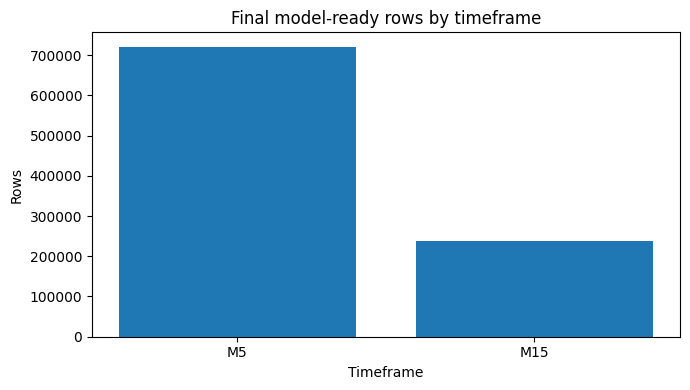

Saved figure: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/01_m5_m15_timeframe_feasibility_eda/figures/mean_abs_target_return_bps_by_timeframe.png


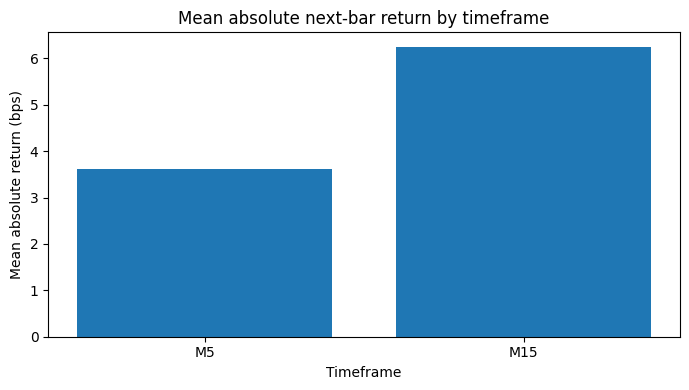

In [9]:
plot_df = summary_display[summary_display['variant'] == 'price_only'].copy()
plt.figure(figsize=(7, 4))
plt.bar(plot_df['timeframe'], plot_df['rows_final'])
plt.title('Final model-ready rows by timeframe')
plt.ylabel('Rows')
plt.xlabel('Timeframe')
save_fig('final_rows_by_timeframe.png')
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(plot_df['timeframe'], plot_df['mean_abs_target_return_bps'])
plt.title('Mean absolute next-bar return by timeframe')
plt.ylabel('Mean absolute return (bps)')
plt.xlabel('Timeframe')
save_fig('mean_abs_target_return_bps_by_timeframe.png')
plt.show()

## 7. Calendar coverage and non-contiguous gap profile

This section checks whether the M5 and M15 bars are temporally coherent and whether the monthly bar counts look stable.

Important reporting note: the source bars are **right-labelled**. A bar timestamped at exactly midnight belongs to the interval that ended at midnight. Therefore, the notebook assigns boundary bars to their **effective month** before producing monthly coverage charts.

Raw M5 and M15 monthly counts should not be interpreted on the same absolute scale because M5 naturally has about three times as many bars as M15. The notebook therefore reports both raw counts and a relative-to-median coverage index.

In [10]:
gap_rows = []
monthly_counts = []

for tf, df in bars.items():
    minutes = TIMEFRAME_MINUTES[tf]
    deltas = df.index.to_series().diff().dropna()
    gaps = deltas[deltas > pd.Timedelta(minutes=minutes)]

    first_ts = df.index.min()
    last_ts = df.index.max()
    calendar_days = max((last_ts - first_ts).total_seconds() / 86400, 1)

    gap_rows.append({
        'timeframe': tf,
        'bar_minutes': minutes,
        'bars': len(df),
        'first_timestamp_utc': first_ts,
        'last_timestamp_utc': last_ts,
        'non_contiguous_gaps': int(len(gaps)),
        'gaps_per_10k_bars': float(len(gaps) / len(df) * 10_000),
        'gaps_per_30_calendar_days': float(len(gaps) / calendar_days * 30),
        'max_gap_minutes': float(gaps.max().total_seconds() / 60) if len(gaps) else minutes,
        'median_gap_minutes': float(gaps.median().total_seconds() / 60) if len(gaps) else np.nan,
    })

    # Bars are right-labelled. The final bar timestamped 2026-04-01 00:00 UTC
    # belongs to the final March 2026 interval, not to a new April 2026 data month.
    # Subtracting 1 nanosecond assigns right-labelled boundary bars to the month
    # whose interval they actually close.
    effective_month = (df.index - pd.Timedelta(nanoseconds=1)).to_period('M').to_timestamp()
    tmp = pd.Series(1, index=effective_month).groupby(level=0).sum().rename('bar_count').to_frame()
    tmp['timeframe'] = tf
    tmp['month'] = pd.to_datetime(tmp.index, utc=True)
    monthly_counts.append(tmp.reset_index(drop=True))

gap_summary = pd.DataFrame(gap_rows)
monthly_counts = pd.concat(monthly_counts, ignore_index=True)

# Raw monthly bar counts are not directly comparable across M5 and M15 because
# M5 naturally has about three times as many bars as M15. For visual comparison,
# add a relative coverage index against each timeframe's own median month.
monthly_counts['median_monthly_bar_count_for_timeframe'] = (
    monthly_counts.groupby('timeframe')['bar_count'].transform('median')
)
monthly_counts['bar_count_relative_to_median_pct'] = (
    monthly_counts['bar_count'] / monthly_counts['median_monthly_bar_count_for_timeframe'] * 100
)

display(gap_summary)
gap_summary.to_csv(TABLE_DIR / 'gap_summary.csv', index=False)
monthly_counts.to_csv(TABLE_DIR / 'monthly_bar_counts.csv', index=False)
monthly_counts.to_csv(TABLE_DIR / 'monthly_bar_counts_with_relative_index.csv', index=False)


,timeframe,bar_minutes,bars,first_timestamp_utc,last_timestamp_utc,non_contiguous_gaps,gaps_per_10k_bars,gaps_per_30_calendar_days,max_gap_minutes,median_gap_minutes
0,M5,5,724552,2016-01-03 23:05:00+00:00,2026-04-01 00:00:00+00:00,3750,51.756120,30.079907,4585.0,65.0
1,M15,15,240636,2016-01-03 23:15:00+00:00,2026-04-01 00:00:00+00:00,3433,142.663608,27.537203,4605.0,75.0


Saved figure: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/01_m5_m15_timeframe_feasibility_eda/figures/monthly_complete_bar_count.png


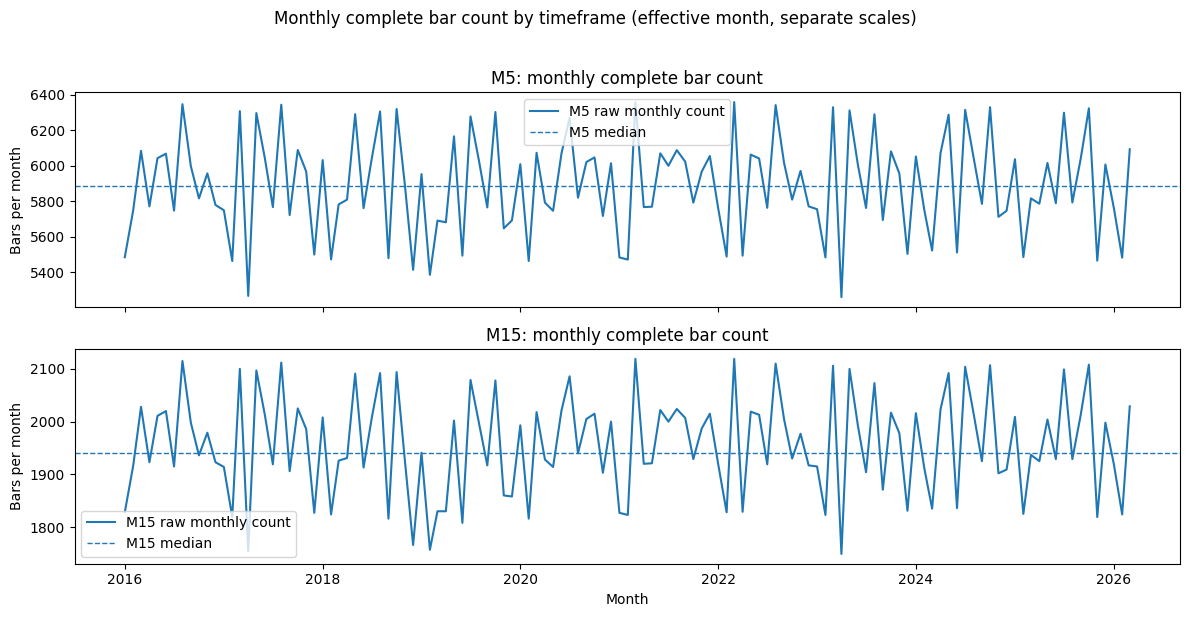

Saved figure: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/01_m5_m15_timeframe_feasibility_eda/figures/monthly_complete_bar_count_relative_to_median.png


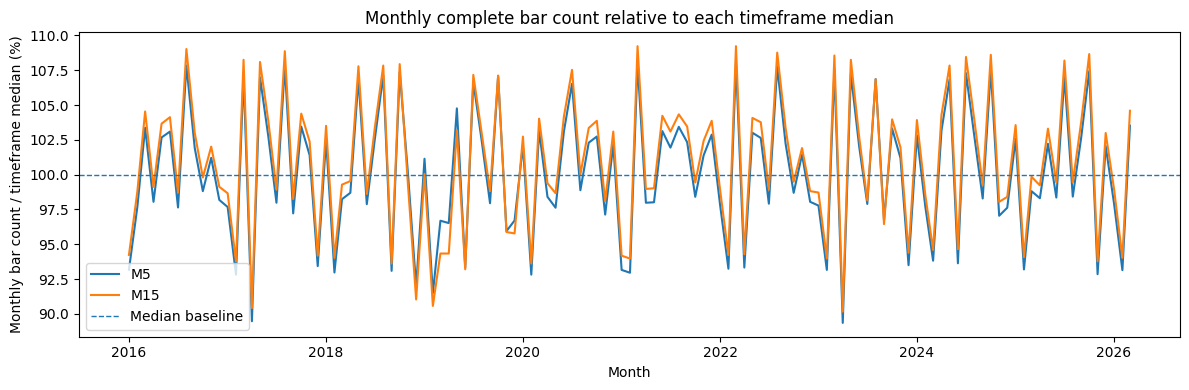

In [11]:
# Raw monthly counts are shown separately by timeframe to avoid a misleading
# same-axis comparison between M5 and M15, since M5 naturally has around 3x more bars.
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for ax, tf in zip(axes, ['M5', 'M15']):
    tmp = monthly_counts[monthly_counts['timeframe'] == tf].copy()
    ax.plot(tmp['month'], tmp['bar_count'], label=f'{tf} raw monthly count')
    ax.axhline(tmp['bar_count'].median(), linestyle='--', linewidth=1, label=f'{tf} median')
    ax.set_title(f'{tf}: monthly complete bar count')
    ax.set_ylabel('Bars per month')
    ax.legend(loc='best')

axes[-1].set_xlabel('Month')
fig.suptitle('Monthly complete bar count by timeframe (effective month, separate scales)', y=1.02)
plt.tight_layout()
save_fig('monthly_complete_bar_count.png')
plt.show()

# Relative coverage index: 100 means the month has the median complete-bar count
# for that timeframe. This is the fairer visual comparison across M5 and M15.
plt.figure(figsize=(12, 4))
for tf in ['M5', 'M15']:
    tmp = monthly_counts[monthly_counts['timeframe'] == tf].copy()
    plt.plot(tmp['month'], tmp['bar_count_relative_to_median_pct'], label=tf)

plt.axhline(100, linestyle='--', linewidth=1, label='Median baseline')
plt.title('Monthly complete bar count relative to each timeframe median')
plt.ylabel('Monthly bar count / timeframe median (%)')
plt.xlabel('Month')
plt.legend()
save_fig('monthly_complete_bar_count_relative_to_median.png')
plt.show()


## 8. Target balance and directional stability

Because the target is directional, class balance must be checked overall and through time. A roughly balanced target is expected for next-bar direction, so accuracy alone should not be treated as sufficient evidence.

In [12]:
target_rows = []
monthly_target = []
for tf in ['M5', 'M15']:
    df = datasets[(tf, 'price_only')]
    y = df['target_dir'].astype(int)
    ret_bps = bps(df['target_ret_fwd'])
    target_rows.append({
        'timeframe': tf,
        'rows': len(df),
        'up_rate': float((y == 1).mean()),
        'down_rate': float((y == 0).mean()),
        'mean_return_bps': float(ret_bps.mean()),
        'mean_abs_return_bps': float(ret_bps.abs().mean()),
        'std_return_bps': float(ret_bps.std()),
        'p05_return_bps': float(ret_bps.quantile(0.05)),
        'p50_return_bps': float(ret_bps.quantile(0.50)),
        'p95_return_bps': float(ret_bps.quantile(0.95)),
    })
    tmp = df.resample('MS').agg(
        rows=('target_dir', 'size'),
        up_rate=('target_dir', 'mean'),
        mean_abs_return_bps=('target_ret_fwd', lambda x: float(np.mean(np.abs(x)) * 10_000)),
        std_return_bps=('target_ret_fwd', lambda x: float(np.std(x, ddof=1) * 10_000)),
    )
    tmp['timeframe'] = tf
    tmp['month'] = tmp.index
    monthly_target.append(tmp.reset_index(drop=True))

target_summary = pd.DataFrame(target_rows)
monthly_target = pd.concat(monthly_target, ignore_index=True)

display(target_summary)
target_summary.to_csv(TABLE_DIR / 'target_balance_return_summary.csv', index=False)
monthly_target.to_csv(TABLE_DIR / 'monthly_target_stability.csv', index=False)

,timeframe,rows,up_rate,down_rate,mean_return_bps,mean_abs_return_bps,std_return_bps,p05_return_bps,p50_return_bps,p95_return_bps
0,M5,720539,0.498534,0.501466,0.009117,3.624223,5.905337,-7.958166,0.00000,8.040000
1,M15,237001,0.501314,0.498686,0.021989,6.248668,10.199067,-13.696415,0.03055,13.734612


Saved figure: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/01_m5_m15_timeframe_feasibility_eda/figures/monthly_target_up_rate.png


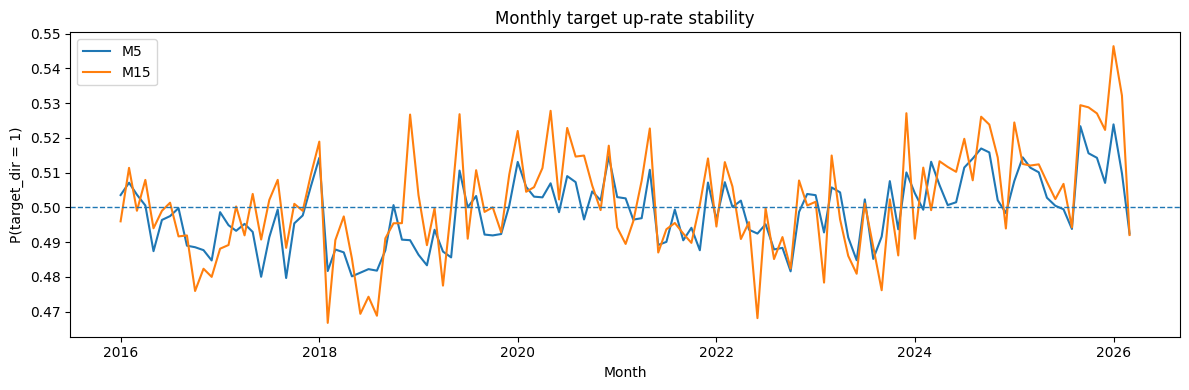

Saved figure: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/01_m5_m15_timeframe_feasibility_eda/figures/monthly_mean_abs_target_return_bps.png


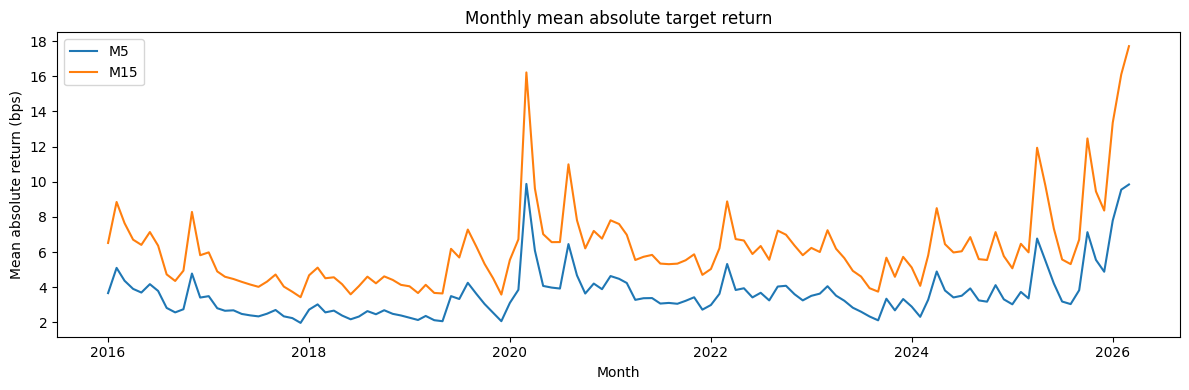

In [13]:
plt.figure(figsize=(12, 4))
for tf in ['M5', 'M15']:
    tmp = monthly_target[monthly_target['timeframe'] == tf]
    plt.plot(tmp['month'], tmp['up_rate'], label=tf)
plt.axhline(0.5, linestyle='--', linewidth=1)
plt.title('Monthly target up-rate stability')
plt.ylabel('P(target_dir = 1)')
plt.xlabel('Month')
plt.legend()
save_fig('monthly_target_up_rate.png')
plt.show()

plt.figure(figsize=(12, 4))
for tf in ['M5', 'M15']:
    tmp = monthly_target[monthly_target['timeframe'] == tf]
    plt.plot(tmp['month'], tmp['mean_abs_return_bps'], label=tf)
plt.title('Monthly mean absolute target return')
plt.ylabel('Mean absolute return (bps)')
plt.xlabel('Month')
plt.legend()
save_fig('monthly_mean_abs_target_return_bps.png')
plt.show()

## 9. Return distribution and volatility profile

This section compares the next-bar return distribution. M15 usually has fewer rows but larger per-bar movement. This matters because a timeframe with tiny average movement may be harder to trade after transaction costs.

In [14]:
return_distribution_rows = []
for tf in ['M5', 'M15']:
    ret = bps(datasets[(tf, 'price_only')]['target_ret_fwd'])
    row = {'timeframe': tf}
    row.update(robust_quantile_summary(ret))
    return_distribution_rows.append(row)

return_distribution = pd.DataFrame(return_distribution_rows)
display(return_distribution)
return_distribution.to_csv(TABLE_DIR / 'target_return_distribution_bps.csv', index=False)

,timeframe,count,mean,std,p01,p05,p25,p50,p75,p95,p99
0,M5,720539,0.009117,5.905337,-16.602695,-7.958166,-2.299835,0.00000,2.352796,8.040000,15.992298
1,M15,237001,0.021989,10.199067,-28.921832,-13.696415,-3.920534,0.03055,4.088926,13.734612,27.655245


Saved figure: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/01_m5_m15_timeframe_feasibility_eda/figures/target_return_distribution_clipped_bps.png


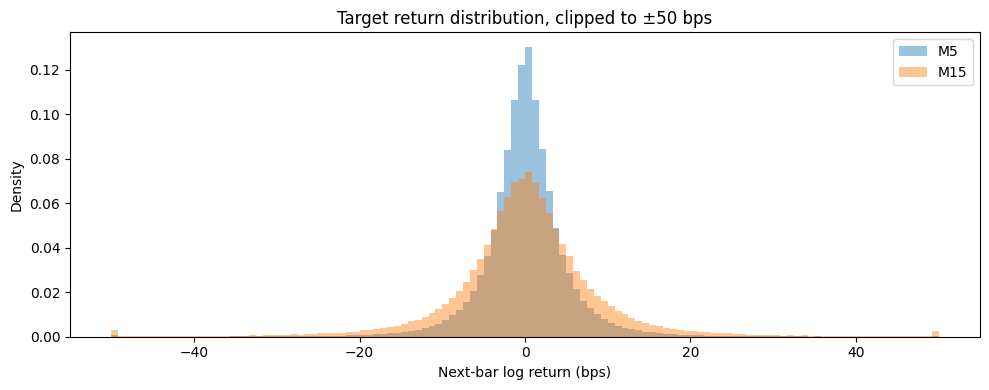

In [15]:
plt.figure(figsize=(10, 4))
for tf in ['M5', 'M15']:
    ret = bps(datasets[(tf, 'price_only')]['target_ret_fwd']).clip(-50, 50)
    plt.hist(ret, bins=120, alpha=0.45, density=True, label=tf)
plt.title('Target return distribution, clipped to ±50 bps')
plt.xlabel('Next-bar log return (bps)')
plt.ylabel('Density')
plt.legend()
save_fig('target_return_distribution_clipped_bps.png')
plt.show()

## 10. Cost-to-return profile

This is a feasibility check, not a strategy backtest. It compares the average absolute next-bar return against the cost grid. If the average movement is small relative to one-way turnover cost, the timeframe may require very selective trading and strict turnover control.

In [16]:
cost_rows = []
for tf in ['M5', 'M15']:
    ret_abs_bps = bps(datasets[(tf, 'price_only')]['target_ret_fwd']).abs()
    for cost in COST_GRID_BPS:
        cost_rows.append({
            'timeframe': tf,
            'one_way_cost_bps': cost,
            'mean_abs_return_bps': float(ret_abs_bps.mean()),
            'median_abs_return_bps': float(ret_abs_bps.median()),
            'p75_abs_return_bps': float(ret_abs_bps.quantile(0.75)),
            'p90_abs_return_bps': float(ret_abs_bps.quantile(0.90)),
            'share_abs_return_gt_one_way_cost': float((ret_abs_bps > cost).mean()) if cost > 0 else 1.0,
            'mean_abs_return_to_one_way_cost': float(ret_abs_bps.mean() / cost) if cost > 0 else np.inf,
        })

cost_profile = pd.DataFrame(cost_rows)
display(cost_profile)
cost_profile.to_csv(TABLE_DIR / 'cost_to_return_profile.csv', index=False)

,timeframe,one_way_cost_bps,mean_abs_return_bps,median_abs_return_bps,p75_abs_return_bps,p90_abs_return_bps,share_abs_return_gt_one_way_cost,mean_abs_return_to_one_way_cost
0,M5,0.0,3.624223,2.327408,4.587839,8.000279,1.000000,inf
1,M5,0.5,3.624223,2.327408,4.587839,8.000279,0.875885,7.248446
2,M5,1.0,3.624223,2.327408,4.587839,8.000279,0.749941,3.624223
3,M5,2.0,3.624223,2.327408,4.587839,8.000279,0.553887,1.812111
4,M5,3.0,3.624223,2.327408,4.587839,8.000279,0.404751,1.208074
5,M5,5.0,3.624223,2.327408,4.587839,8.000279,0.221418,0.724845
6,M15,0.0,6.248668,4.001749,7.854809,13.717851,1.000000,inf
7,M15,0.5,6.248668,4.001749,7.854809,13.717851,0.928439,12.497335
8,M15,1.0,6.248668,4.001749,7.854809,13.717851,0.855064,6.248668
9,M15,2.0,6.248668,4.001749,7.854809,13.717851,0.721297,3.124334


Saved figure: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/01_m5_m15_timeframe_feasibility_eda/figures/share_abs_return_exceeds_cost.png


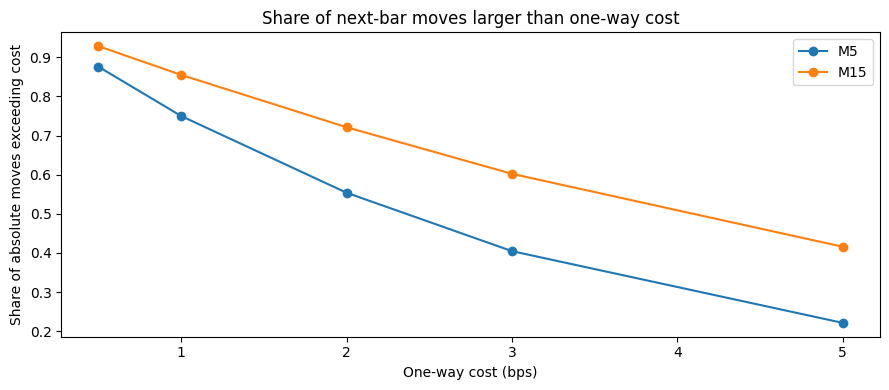

In [17]:
plt.figure(figsize=(9, 4))
for tf in ['M5', 'M15']:
    tmp = cost_profile[(cost_profile['timeframe'] == tf) & (cost_profile['one_way_cost_bps'] > 0)]
    plt.plot(tmp['one_way_cost_bps'], tmp['share_abs_return_gt_one_way_cost'], marker='o', label=tf)
plt.title('Share of next-bar moves larger than one-way cost')
plt.xlabel('One-way cost (bps)')
plt.ylabel('Share of absolute moves exceeding cost')
plt.legend()
save_fig('share_abs_return_exceeds_cost.png')
plt.show()

## 11. Turnover pressure proxy

The actual turnover will depend on model signals and probability thresholds, which are not available in this EDA notebook. However, a useful proxy is the natural direction flip rate in the target. If direction changes frequently, a naïve always-follow-direction strategy would create high turnover pressure.

In [18]:
turnover_proxy_rows = []
for tf in ['M5', 'M15']:
    df = datasets[(tf, 'price_only')]
    y = df['target_dir'].astype(int)
    flips = y.ne(y.shift(1)).fillna(False)
    minutes = TIMEFRAME_MINUTES[tf]
    bars_per_day_approx = int(round(24 * 60 / minutes))
    turnover_proxy_rows.append({
        'timeframe': tf,
        'rows': len(y),
        'target_flip_rate_per_bar': float(flips.mean()),
        'approx_direction_flips_per_24h_if_always_in_market': float(flips.mean() * bars_per_day_approx),
        'bars_per_24h': bars_per_day_approx,
        'minimum_hold_bars_planned': 2,
        'minimum_hold_minutes_planned': 2 * minutes,
        'max_position_changes_per_day_planned': 5,
    })

turnover_proxy = pd.DataFrame(turnover_proxy_rows)
display(turnover_proxy)
turnover_proxy.to_csv(TABLE_DIR / 'turnover_pressure_proxy.csv', index=False)

,timeframe,rows,target_flip_rate_per_bar,approx_direction_flips_per_24h_if_always_in_market,bars_per_24h,minimum_hold_bars_planned,minimum_hold_minutes_planned,max_position_changes_per_day_planned
0,M5,720539,0.515198,148.376923,288,2,10,5
1,M15,237001,0.516584,49.592095,96,2,30,5


## 12. Volume-assisted feature behaviour

This section audits `volume_z20`, the only additional feature in the volume-assisted dataset. The goal is to check whether it behaves as a normalised pressure feature and whether its distribution changes severely through time.

In [19]:
volume_rows = []
monthly_volume = []
for tf in ['M5', 'M15']:
    df = datasets[(tf, 'volume_assisted')]
    if 'volume_z20' not in df.columns:
        raise ValueError(f'{tf} volume-assisted dataset does not contain volume_z20')
    vz = df['volume_z20']
    volume_rows.append({
        'timeframe': tf,
        'count': int(vz.count()),
        'mean': float(vz.mean()),
        'std': float(vz.std()),
        'p01': float(vz.quantile(0.01)),
        'p05': float(vz.quantile(0.05)),
        'p50': float(vz.quantile(0.50)),
        'p95': float(vz.quantile(0.95)),
        'p99': float(vz.quantile(0.99)),
        'abs_gt_3_rate': float((vz.abs() > 3).mean()),
        'abs_gt_5_rate': float((vz.abs() > 5).mean()),
    })
    tmp = df['volume_z20'].resample('MS').agg(['mean', 'std'])
    tmp['timeframe'] = tf
    tmp['month'] = tmp.index
    monthly_volume.append(tmp.reset_index(drop=True))

volume_summary = pd.DataFrame(volume_rows)
monthly_volume = pd.concat(monthly_volume, ignore_index=True)

display(volume_summary)
volume_summary.to_csv(TABLE_DIR / 'volume_z20_distribution_summary.csv', index=False)
monthly_volume.to_csv(TABLE_DIR / 'monthly_volume_z20_summary.csv', index=False)

,timeframe,count,mean,std,p01,p05,p50,p95,p99,abs_gt_3_rate,abs_gt_5_rate
0,M5,720539,0.016461,1.125572,-1.920084,-1.475134,-0.196870,2.180593,3.186362,0.014231,0.0
1,M15,237001,0.059264,1.160812,-1.950308,-1.483946,-0.142392,2.242539,3.147856,0.013966,0.0


Saved figure: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/01_m5_m15_timeframe_feasibility_eda/figures/volume_z20_distribution_clipped.png


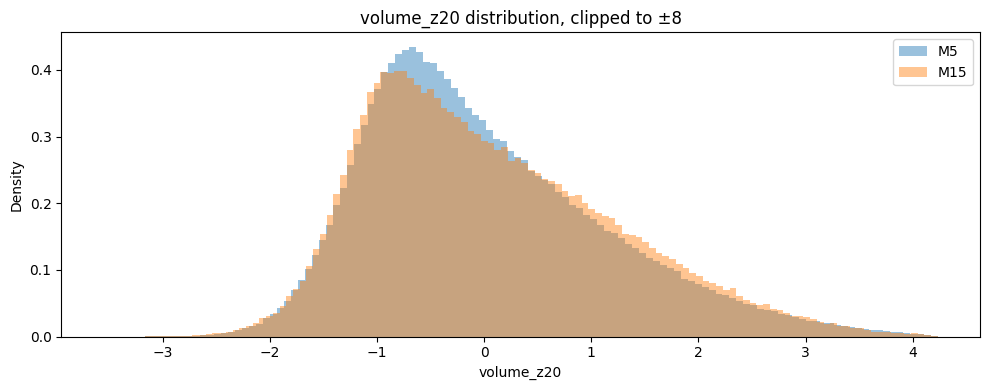

In [20]:
plt.figure(figsize=(10, 4))
for tf in ['M5', 'M15']:
    vz = datasets[(tf, 'volume_assisted')]['volume_z20'].clip(-8, 8)
    plt.hist(vz, bins=120, alpha=0.45, density=True, label=tf)
plt.title('volume_z20 distribution, clipped to ±8')
plt.xlabel('volume_z20')
plt.ylabel('Density')
plt.legend()
save_fig('volume_z20_distribution_clipped.png')
plt.show()

## 13. Feature drift and stability

This section measures feature drift year by year against an early historical reference period. The purpose is to identify features that may be unstable across regimes. PSI is used as a simple screening statistic, not as a formal hypothesis test.

Interpretation guide:

```text
PSI < 0.10   low drift
0.10–0.25    moderate drift
> 0.25       high drift
```

The final dataset ends in March 2026, so 2026 is a partial year. The notebook still saves all-year drift values for transparency, but excludes a partial final year from the feasibility score to avoid over-weighting an incomplete calendar year.


In [21]:
DRIFT_FEATURE_CANDIDATES = [
    'log_ret_1', 'log_ret_6', 'log_ret_12', 'high_low_range_pct', 'open_to_close_pct',
    'close_sma_20_ratio', 'close_ema_20_ratio', 'rolling_vol_20', 'roc_10',
    'rsi_14', 'atr_pct_14', 'bb_width_pct_20', 'bb_position_20',
    'minute_of_day_sin', 'day_of_week_sin', 'is_after_gap'
]

EXCLUDE_PARTIAL_FINAL_YEAR_FROM_DRIFT_SCORE = True

drift_rows = []
for tf in ['M5', 'M15']:
    df = datasets[(tf, 'price_only')]
    years = sorted(df.index.year.unique())
    reference_years = years[:3]  # early historical reference block
    ref = df[df.index.year.isin(reference_years)]

    year_counts = df.groupby(df.index.year).size()
    non_final_year_counts = year_counts.loc[year_counts.index < max(years)]
    median_full_year_rows = float(non_final_year_counts.median()) if len(non_final_year_counts) else float(year_counts.median())
    partial_threshold = 0.75 * median_full_year_rows

    for col in DRIFT_FEATURE_CANDIDATES:
        if col not in df.columns:
            continue
        for year in years[3:]:
            cur = df[df.index.year == year]
            is_partial_final_year = bool((year == max(years)) and (len(cur) < partial_threshold))
            drift_rows.append({
                'timeframe': tf,
                'feature': col,
                'reference_years': f'{reference_years[0]}-{reference_years[-1]}',
                'comparison_year': int(year),
                'year_rows': int(len(cur)),
                'is_partial_final_year': is_partial_final_year,
                'used_in_drift_score': not (EXCLUDE_PARTIAL_FINAL_YEAR_FROM_DRIFT_SCORE and is_partial_final_year),
                'psi': psi(ref[col], cur[col], bins=10),
            })

drift = pd.DataFrame(drift_rows)

feature_drift_summary_all_years = (
    drift.groupby(['timeframe', 'feature'], as_index=False)
    .agg(mean_psi=('psi', 'mean'), max_psi=('psi', 'max'), high_drift_years=('psi', lambda x: int((x > 0.25).sum())))
    .sort_values(['timeframe', 'max_psi'], ascending=[True, False])
)

drift_for_score = drift[drift['used_in_drift_score']].copy()
feature_drift_summary = (
    drift_for_score.groupby(['timeframe', 'feature'], as_index=False)
    .agg(mean_psi=('psi', 'mean'), max_psi=('psi', 'max'), high_drift_years=('psi', lambda x: int((x > 0.25).sum())))
    .sort_values(['timeframe', 'max_psi'], ascending=[True, False])
)

display(feature_drift_summary.head(30))
drift.to_csv(TABLE_DIR / 'feature_drift_yearly_psi.csv', index=False)
feature_drift_summary_all_years.to_csv(TABLE_DIR / 'feature_drift_summary_all_years.csv', index=False)
feature_drift_summary.to_csv(TABLE_DIR / 'feature_drift_summary.csv', index=False)


,timeframe,feature,mean_psi,max_psi,high_drift_years
0,M15,atr_pct_14,0.331163,0.924016,3
14,M15,rolling_vol_20,0.273257,0.750842,3
6,M15,high_low_range_pct,0.196440,0.548149,2
2,M15,bb_width_pct_20,0.168501,0.536352,2
9,M15,log_ret_12,0.060299,0.191164,0
3,M15,close_ema_20_ratio,0.059650,0.188935,0
4,M15,close_sma_20_ratio,0.058581,0.187314,0
13,M15,roc_10,0.058707,0.182902,0
10,M15,log_ret_6,0.056391,0.178004,0
12,M15,open_to_close_pct,0.062123,0.160971,0


Saved figure: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/01_m5_m15_timeframe_feasibility_eda/figures/m5_top_feature_drift_psi.png


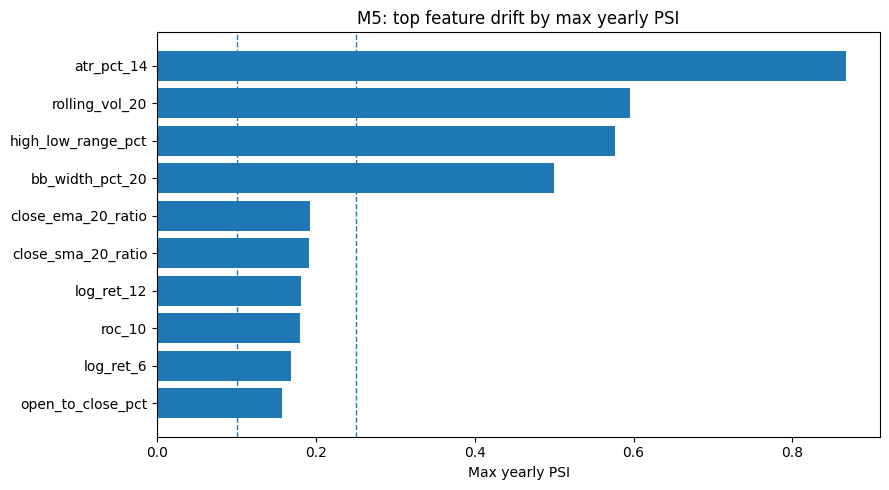

Saved figure: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/01_m5_m15_timeframe_feasibility_eda/figures/m15_top_feature_drift_psi.png


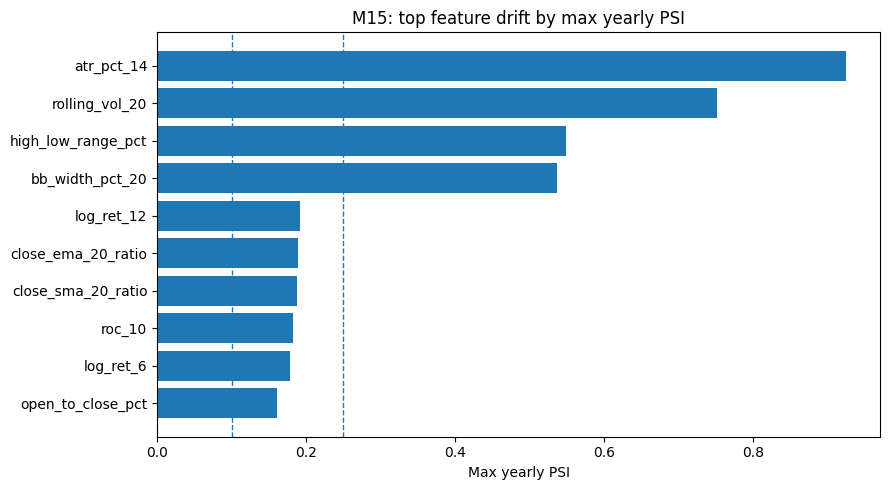

In [22]:
for tf in ['M5', 'M15']:
    top = feature_drift_summary[feature_drift_summary['timeframe'] == tf].head(10).sort_values('max_psi')
    plt.figure(figsize=(9, 5))
    plt.barh(top['feature'], top['max_psi'])
    plt.axvline(0.10, linestyle='--', linewidth=1)
    plt.axvline(0.25, linestyle='--', linewidth=1)
    plt.title(f'{tf}: top feature drift by max yearly PSI')
    plt.xlabel('Max yearly PSI')
    save_fig(f'{tf.lower()}_top_feature_drift_psi.png')
    plt.show()

## 14. Simple autocorrelation and predictability sanity checks

This is not modelling. It checks whether next-bar returns show obvious serial dependence. A near-zero autocorrelation does not mean models cannot learn nonlinear patterns, but it warns that directional prediction may be difficult.

In [23]:
autocorr_rows = []
for tf in ['M5', 'M15']:
    ret = datasets[(tf, 'price_only')]['target_ret_fwd']
    y = datasets[(tf, 'price_only')]['target_dir'].astype(int)
    for lag in [1, 2, 3, 6, 12, 24, 48]:
        if lag < len(ret):
            autocorr_rows.append({
                'timeframe': tf,
                'lag_bars': lag,
                'lag_minutes': lag * TIMEFRAME_MINUTES[tf],
                'return_autocorr': float(ret.autocorr(lag=lag)),
                'direction_autocorr': float(y.autocorr(lag=lag)),
            })

autocorr_summary = pd.DataFrame(autocorr_rows)
display(autocorr_summary)
autocorr_summary.to_csv(TABLE_DIR / 'return_direction_autocorrelation.csv', index=False)

,timeframe,lag_bars,lag_minutes,return_autocorr,direction_autocorr
0,M5,1,5,-0.016315,-0.030403
1,M5,2,10,-0.001665,-0.012384
2,M5,3,15,0.001982,-0.009801
3,M5,6,30,-0.000077,-0.002081
4,M5,12,60,0.001408,0.000193
5,M5,24,120,0.001329,0.000684
6,M5,48,240,-0.001943,-0.000074
7,M15,1,15,-0.009538,-0.033172
8,M15,2,30,0.001870,-0.013935
9,M15,3,45,-0.010327,-0.011889


Saved figure: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/01_m5_m15_timeframe_feasibility_eda/figures/return_autocorrelation_by_lag.png


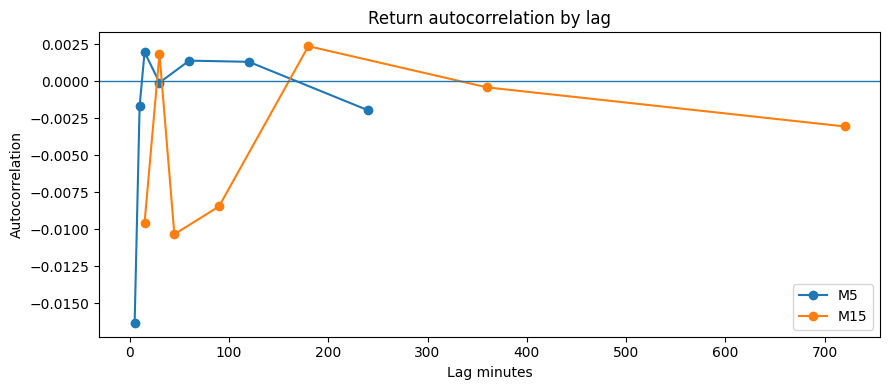

In [24]:
plt.figure(figsize=(9, 4))
for tf in ['M5', 'M15']:
    tmp = autocorr_summary[autocorr_summary['timeframe'] == tf]
    plt.plot(tmp['lag_minutes'], tmp['return_autocorr'], marker='o', label=tf)
plt.axhline(0, linewidth=1)
plt.title('Return autocorrelation by lag')
plt.xlabel('Lag minutes')
plt.ylabel('Autocorrelation')
plt.legend()
save_fig('return_autocorrelation_by_lag.png')
plt.show()

## 15. Walk-forward fold sufficiency

The later modelling notebooks will use walk-forward evaluation. This section checks whether each timeframe has enough rows in each proposed fold for LightGBM, LSTM, and CNN-LSTM.

The default fold design below is intentionally editable. It preserves a final holdout period and evaluates multiple unseen test windows before that final holdout.

In [25]:
# Editable fold plan for feasibility screening.
# These dates are only for feasibility planning; final modelling notebooks may refine them after Notebook 2.
FOLD_PLAN = [
    {'fold': 1, 'train_start': '2016-01-01', 'train_end': '2020-12-31 23:59:59', 'val_start': '2021-01-01', 'val_end': '2021-12-31 23:59:59', 'test_start': '2022-01-01', 'test_end': '2022-12-31 23:59:59'},
    {'fold': 2, 'train_start': '2016-01-01', 'train_end': '2021-12-31 23:59:59', 'val_start': '2022-01-01', 'val_end': '2022-12-31 23:59:59', 'test_start': '2023-01-01', 'test_end': '2023-12-31 23:59:59'},
    {'fold': 3, 'train_start': '2016-01-01', 'train_end': '2022-12-31 23:59:59', 'val_start': '2023-01-01', 'val_end': '2023-12-31 23:59:59', 'test_start': '2024-01-01', 'test_end': '2024-12-31 23:59:59'},
]

FINAL_HOLDOUT = {'start': '2025-01-01', 'end': '2026-03-31 23:59:59'}


def utc_ts(x):
    return pd.Timestamp(x, tz='UTC')

fold_rows = []
for tf in ['M5', 'M15']:
    df = datasets[(tf, 'price_only')]
    for fold in FOLD_PLAN:
        for split in ['train', 'val', 'test']:
            start = utc_ts(fold[f'{split}_start'])
            end = utc_ts(fold[f'{split}_end'])
            part = df.loc[(df.index >= start) & (df.index <= end)]
            fold_rows.append({
                'timeframe': tf,
                'fold': fold['fold'],
                'split': split,
                'start': start,
                'end': end,
                'rows': len(part),
                'up_rate': float(part['target_dir'].mean()) if len(part) else np.nan,
                'mean_abs_return_bps': float(part['target_ret_fwd'].abs().mean() * 10_000) if len(part) else np.nan,
            })
    holdout = df.loc[(df.index >= utc_ts(FINAL_HOLDOUT['start'])) & (df.index <= utc_ts(FINAL_HOLDOUT['end']))]
    fold_rows.append({
        'timeframe': tf,
        'fold': 'final_holdout',
        'split': 'holdout',
        'start': utc_ts(FINAL_HOLDOUT['start']),
        'end': utc_ts(FINAL_HOLDOUT['end']),
        'rows': len(holdout),
        'up_rate': float(holdout['target_dir'].mean()) if len(holdout) else np.nan,
        'mean_abs_return_bps': float(holdout['target_ret_fwd'].abs().mean() * 10_000) if len(holdout) else np.nan,
    })

fold_sufficiency = pd.DataFrame(fold_rows)
display(fold_sufficiency)
fold_sufficiency.to_csv(TABLE_DIR / 'walk_forward_fold_sufficiency.csv', index=False)

,timeframe,fold,split,start,end,rows,up_rate,mean_abs_return_bps
0,M5,1,train,2016-01-01 00:00:00+00:00,2020-12-31 23:59:59+00:00,350722,0.495455,3.298715
1,M5,1,val,2021-01-01 00:00:00+00:00,2021-12-31 23:59:59+00:00,70558,0.497180,3.494411
2,M5,1,test,2022-01-01 00:00:00+00:00,2022-12-31 23:59:59+00:00,70571,0.495444,3.768218
3,M5,2,train,2016-01-01 00:00:00+00:00,2021-12-31 23:59:59+00:00,421280,0.495744,3.331491
4,M5,2,val,2022-01-01 00:00:00+00:00,2022-12-31 23:59:59+00:00,70571,0.495444,3.768218
5,M5,2,test,2023-01-01 00:00:00+00:00,2023-12-31 23:59:59+00:00,70003,0.497564,3.103438
6,M5,3,train,2016-01-01 00:00:00+00:00,2022-12-31 23:59:59+00:00,491851,0.495701,3.394153
7,M5,3,val,2023-01-01 00:00:00+00:00,2023-12-31 23:59:59+00:00,70003,0.497564,3.103438
8,M5,3,test,2024-01-01 00:00:00+00:00,2024-12-31 23:59:59+00:00,70829,0.507038,3.505946
9,M5,final_holdout,holdout,2025-01-01 00:00:00+00:00,2026-03-31 23:59:59+00:00,87856,0.508309,5.422552


Saved figure: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/01_m5_m15_timeframe_feasibility_eda/figures/m5_walk_forward_fold_rows.png


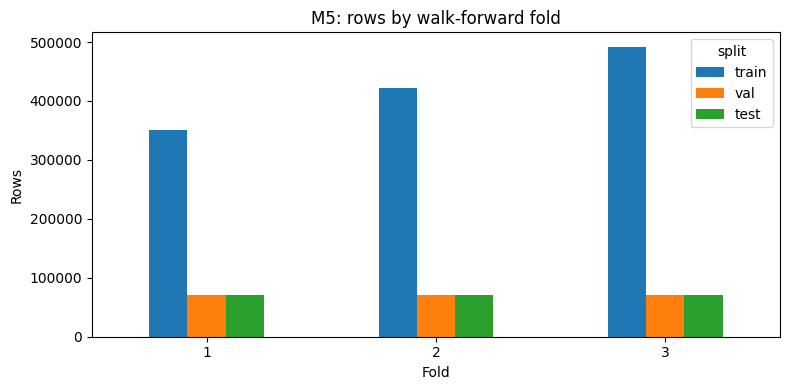

Saved figure: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/01_m5_m15_timeframe_feasibility_eda/figures/m15_walk_forward_fold_rows.png


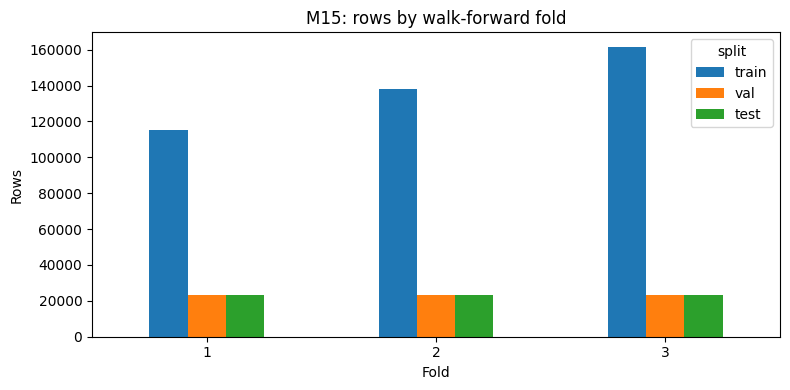

In [26]:
fold_plot = fold_sufficiency[fold_sufficiency['split'].isin(['train', 'val', 'test'])].copy()
for tf in ['M5', 'M15']:
    tmp = fold_plot[fold_plot['timeframe'] == tf]
    pivot = tmp.pivot(index='fold', columns='split', values='rows')
    pivot = pivot[['train', 'val', 'test']]
    ax = pivot.plot(kind='bar', figsize=(8, 4))
    ax.set_title(f'{tf}: rows by walk-forward fold')
    ax.set_xlabel('Fold')
    ax.set_ylabel('Rows')
    plt.xticks(rotation=0)
    save_fig(f'{tf.lower()}_walk_forward_fold_rows.png')
    plt.show()

## 16. Timeframe feasibility scoring

This scoring table is not a final decision rule. It helps summarise the evidence. The final timeframe should be chosen after this EDA and the lightweight benchmark notebook.

Scoring direction:

- More rows is better for model training.
- Higher mean absolute return is better for surviving costs.
- Lower gap frequency per calendar time is better.
- Lower estimated daily turnover pressure is better.
- Higher fold sufficiency is better.
- Lower feature drift is better.

Methodological caution: because there are only two timeframe candidates, min-max scoring is sensitive. Treat this as a summary table, not as an automatic decision rule.


In [27]:
def minmax_score(values: pd.Series, higher_is_better: bool = True) -> pd.Series:
    values = values.astype(float)
    if values.max() == values.min():
        return pd.Series(0.5, index=values.index)
    score = (values - values.min()) / (values.max() - values.min())
    return score if higher_is_better else 1 - score

score_base = target_summary.merge(gap_summary[['timeframe', 'gaps_per_30_calendar_days']], on='timeframe', how='left')

# Use daily flip pressure rather than per-bar flip rate because M5 and M15 have different bar frequencies.
turn = turnover_proxy[['timeframe', 'approx_direction_flips_per_24h_if_always_in_market']]
score_base = score_base.merge(turn, on='timeframe', how='left')

fold_min = fold_sufficiency[fold_sufficiency['split'].isin(['train', 'val', 'test'])].groupby('timeframe')['rows'].min().rename('min_fold_rows').reset_index()
score_base = score_base.merge(fold_min, on='timeframe', how='left')

# Uses feature_drift_summary that excludes partial final-year drift from the score.
drift_max = feature_drift_summary.groupby('timeframe')['max_psi'].mean().rename('avg_max_feature_psi').reset_index()
score_base = score_base.merge(drift_max, on='timeframe', how='left')

score_base['score_rows'] = minmax_score(score_base['rows'], True)
score_base['score_return_magnitude'] = minmax_score(score_base['mean_abs_return_bps'], True)
score_base['score_gap_frequency'] = minmax_score(score_base['gaps_per_30_calendar_days'], False)
score_base['score_turnover_pressure'] = minmax_score(score_base['approx_direction_flips_per_24h_if_always_in_market'], False)
score_base['score_fold_sufficiency'] = minmax_score(score_base['min_fold_rows'], True)
score_base['score_feature_drift'] = minmax_score(score_base['avg_max_feature_psi'], False)

score_cols = [
    'score_rows', 'score_return_magnitude', 'score_gap_frequency',
    'score_turnover_pressure', 'score_fold_sufficiency', 'score_feature_drift'
]
score_base['eda_feasibility_score_equal_weight'] = score_base[score_cols].mean(axis=1)

feasibility_score = score_base[[
    'timeframe', 'rows', 'mean_abs_return_bps', 'gaps_per_30_calendar_days',
    'approx_direction_flips_per_24h_if_always_in_market',
    'min_fold_rows', 'avg_max_feature_psi',
    *score_cols, 'eda_feasibility_score_equal_weight'
]].sort_values('eda_feasibility_score_equal_weight', ascending=False)

display(feasibility_score)
feasibility_score.to_csv(TABLE_DIR / 'eda_timeframe_feasibility_score.csv', index=False)


,timeframe,rows,mean_abs_return_bps,gaps_per_30_calendar_days,approx_direction_flips_per_24h_if_always_in_market,min_fold_rows,avg_max_feature_psi,score_rows,score_return_magnitude,score_gap_frequency,score_turnover_pressure,score_fold_sufficiency,score_feature_drift,eda_feasibility_score_equal_weight
0,M5,720539,3.624223,30.079907,148.376923,70003,0.252443,1.0,0.0,0.0,0.0,1.0,1.0,0.5
1,M15,237001,6.248668,27.537203,49.592095,22985,0.269181,0.0,1.0,1.0,1.0,0.0,0.0,0.5


## 17. Automated EDA findings draft

This cell generates a cautious, report-ready findings draft based on the computed outputs. Treat it as a starting point and revise after reviewing the plots.

In [28]:
score_sorted = feasibility_score.sort_values('eda_feasibility_score_equal_weight', ascending=False).reset_index(drop=True)
top_score = float(score_sorted.loc[0, 'eda_feasibility_score_equal_weight'])
second_score = float(score_sorted.loc[1, 'eda_feasibility_score_equal_weight']) if len(score_sorted) > 1 else np.nan

if len(score_sorted) > 1 and abs(top_score - second_score) < 0.05:
    preferred_sentence = "The equal-weight EDA score does not produce a decisive timeframe winner."
else:
    preferred_sentence = f"Based on the equal-weight EDA feasibility score, the provisional EDA preference is {score_sorted.loc[0, 'timeframe']}."

m5_rows = int(target_summary.loc[target_summary['timeframe'] == 'M5', 'rows'].iloc[0])
m15_rows = int(target_summary.loc[target_summary['timeframe'] == 'M15', 'rows'].iloc[0])
m5_abs = float(target_summary.loc[target_summary['timeframe'] == 'M5', 'mean_abs_return_bps'].iloc[0])
m15_abs = float(target_summary.loc[target_summary['timeframe'] == 'M15', 'mean_abs_return_bps'].iloc[0])
m5_up = float(target_summary.loc[target_summary['timeframe'] == 'M5', 'up_rate'].iloc[0])
m15_up = float(target_summary.loc[target_summary['timeframe'] == 'M15', 'up_rate'].iloc[0])

findings = f"""
EDA summary draft
=================

1. The regenerated M5 and M15 datasets passed the integrity gate before EDA. This supports using them for timeframe feasibility analysis.

2. M5 provides substantially more model-ready observations ({m5_rows:,}) than M15 ({m15_rows:,}), which is beneficial for model estimation, especially for sequence-based models.

3. M15 has a larger mean absolute next-bar return ({m15_abs:.2f} bps) than M5 ({m5_abs:.2f} bps). This may make M15 more resilient to transaction costs, although it has fewer observations.

4. The binary direction target is close to balanced in both timeframes: M5 up-rate = {m5_up:.4f}; M15 up-rate = {m15_up:.4f}. Therefore, accuracy alone is not sufficient for later model evaluation.

5. The monthly bar-count view uses effective-month assignment for right-labelled bars and includes a relative-to-median coverage index, so it should not be misread as April 2026 coverage or as a direct raw-count comparison between M5 and M15.

6. The cost-to-return profile and turnover proxy should be treated as important screening evidence. A timeframe with more rows is not automatically better if expected movement is too small relative to trading costs.

7. {preferred_sentence} This should not be treated as final model selection. The next notebook should run a lightweight walk-forward LightGBM benchmark on M5 and M15 before selecting the final modelling timeframe.
"""

print(findings)
(OUTPUT_DIR / 'eda_findings_draft.txt').write_text(findings, encoding='utf-8')



EDA summary draft

1. The regenerated M5 and M15 datasets passed the integrity gate before EDA. This supports using them for timeframe feasibility analysis.

2. M5 provides substantially more model-ready observations (720,539) than M15 (237,001), which is beneficial for model estimation, especially for sequence-based models.

3. M15 has a larger mean absolute next-bar return (6.25 bps) than M5 (3.62 bps). This may make M15 more resilient to transaction costs, although it has fewer observations.

4. The binary direction target is close to balanced in both timeframes: M5 up-rate = 0.4985; M15 up-rate = 0.5013. Therefore, accuracy alone is not sufficient for later model evaluation.

5. The monthly bar-count view uses effective-month assignment for right-labelled bars and includes a relative-to-median coverage index, so it should not be misread as April 2026 coverage or as a direct raw-count comparison between M5 and M15.

6. The cost-to-return profile and turnover proxy should be treated

1435

## 18. Output inventory

All generated EDA tables and figures are saved under:

```text
data/capstone_methodology/notebook_outputs/01_m5_m15_timeframe_feasibility_eda/
```

Send the zipped `notebook_outputs/01_m5_m15_timeframe_feasibility_eda` folder for review after execution.

In [29]:
print('Tables saved:')
for path in sorted(TABLE_DIR.glob('*.csv')):
    print(' -', path)

print('\nFigures saved:')
for path in sorted(FIG_DIR.glob('*.png')):
    print(' -', path)

print('\nDraft findings:', OUTPUT_DIR / 'eda_findings_draft.txt')

Tables saved:
 - /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/01_m5_m15_timeframe_feasibility_eda/tables/cost_to_return_profile.csv
 - /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/01_m5_m15_timeframe_feasibility_eda/tables/dataset_size_feature_target_summary.csv
 - /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/01_m5_m15_timeframe_feasibility_eda/tables/eda_input_dataset_summary.csv
 - /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/01_m5_m15_timeframe_feasibility_eda/tables/eda_input_resample_summary.csv
 - /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/01_m5_m15_timeframe_feasibility_eda/tables/eda_timeframe_feasibility_score.csv
 - /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/01_m5_m15_timeframe_feasibility_eda/tables/feature_drift_summary.csv
 - /conten